# Pawnee National Grassland Land Swap
- **Objective:** The workflow in this notebook calculates a contiguity score for groups of federally owned National Grassland parcels. It then uses state parcel data to identify where land swaps between federal and state parcels can occur. It calculates which parcel swaps will have a net increase in contiguity for a group and outputs the results on a map
- **Author:** Max Warnock
- **Code review and/or edits:** 
- **Date:** April 21, 2026
- **Last date of revision:** April 21, 2026

---
### 🛠️ Prerequisites & Setup
* **Libraries:** ex: `pandas`, `scikit-learn`, `matplotlib`
* **Data Sources:** ex: `/data/raw/dataset.csv`
* **Related Notebooks:** ex: [Link to previous step]

### 🏗️ Methodology
1.  **Data Loading:** ex: Read from SQL
2.  **Cleaning:** ex: Handle outliers
3.  **Visualization:** ex: Plot distributions

### ⚡ Troubleshooting/Notes
* Example Note: If data updates, run `01_refresh.ipynb` first.

---


### Import Libraries

In [1]:
### file paths, OS operations, utilities
import os
import pathlib
import zipfile
import time
from glob import glob
from getpass import getpass
from collections import defaultdict

### data handling
import pandas as pd
import geopandas as gpd
import numpy as np

### graph analysis
import networkx as nx

### geometry operations
from shapely.ops import unary_union

### web requests / data download
import requests

### geospatial visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import contextily as ctx
import holoviews as hv
import hvplot.pandas
import cartopy.crs as ccrs

### GBIF API access
import pygbif.occurrences as occ
import pygbif.species as species

### Root directory

In [2]:
### set up root file path
_cwd = pathlib.Path(os.getcwd()).resolve()
repo_root = next(
    (p for p in [_cwd] + list(_cwd.parents) if (p / '.git').exists()),
    _cwd
)
os.chdir(repo_root)

data_dir = os.path.join(repo_root, 'data')
os.makedirs(data_dir, exist_ok=True)

### figures output directory
figures_dir = os.path.join(repo_root, 'figures')

print(f'Repo root: {repo_root}')

Repo root: C:\Users\warno\Documents\GitHub\Pawnee-Grasslands-Project


### Call in boundary and parcel data created in the "boundaries" notebook

In [3]:
### root dir
data_dir = os.path.join(repo_root, 'data')

### connectivity output dir
connectivity_dir = os.path.join(data_dir, 'connectivity')

### main boundary dir
boundary_dir = os.path.join(data_dir, 'boundaries')

### boundary dir for processed data for Western Pawnee
boundary_dir_west = os.path.join(boundary_dir, 'boundary-data-final-west')


### MASTER
### master boundary dir
master_bound_west = os.path.join(boundary_dir_west, 'master_boundary')

### master boundary shapefile
master_bound_west_path = os.path.join(master_bound_west, "pawnee_master_west.shp")

### master boundary convert to gdf
master_bound_west_gdf = gpd.read_file(master_bound_west_path)


### FEDERAL
### federal boundary dir
federal_bound_west = os.path.join(boundary_dir_west, 'federal_boundary')

### federal boundary shapefile 
federal_bound_west_path = os.path.join(federal_bound_west, 'pawnee_fed_west.shp')

### federal boundary convert to gdf
federal_bound_west_gdf = gpd.read_file(federal_bound_west_path)


### STATE
### state boundary dir
state_bound_west = os.path.join(boundary_dir_west, 'state_boundary')

### state boundary shapefile 
state_bound_west_path = os.path.join(state_bound_west, 'pawnee_state_west.shp')

### state boundary convert to gdf
state_bound_west_gdf = gpd.read_file(state_bound_west_path)


### PARCEL
### parcel boundary dir
parcel_bound_west = os.path.join(boundary_dir_west, 'parcel_boundary')

### parcel boundary shapefile 
parcel_bound_west_path = os.path.join(parcel_bound_west, 'pawnee_parcel_west.shp')

### parcel boundary convert to gdf
parcel_bound_west_gdf = gpd.read_file(parcel_bound_west_path)

In [4]:
### view the contents of the parcel gdf
parcel_bound_west_gdf.head()

,PARCEL,MHSPACE,ACCOUNTTYP,ACCOUNTNO,NAME,ADDRESS1,ADDRESS2,CITY,STATE,ZIPCODE,...,Shape_Leng,RECEPTION_,AddressPre,LGLANDASD,LGIMPASD,TOTALLGASD,SCLANDASD,SCIMPASD,TOTALSCASD,geometry
0,054931400001,NaN,R,R8941189,RANALLI ANTHONY M,24989 COUNTY ROAD 86,NaN,AULT,CO,806109502,...,1866.542872,4114944,None,5070.0,28230.0,33300.0,5710.0,31840.0,37550.0,"POLYGON ((-104.58292 40.61056, -104.58294 40.6..."
1,054932300001,0,R,R6778534,MOUNTAIN TOWER & LAND LLC,1224 W PLATTE AVE,NaN,FORT MORGAN,CO,807012949,...,2644.440577,3692193,None,28750.0,0.0,28750.0,28750.0,0.0,28750.0,"POLYGON ((-104.5734 40.61115, -104.57344 40.60..."
2,054931400023,NaN,R,R8985110,NICKS COBY S,3431 WINDSOR CT,NaN,LOVELAND,CO,805384977,...,5195.843311,5088272,None,210.0,0.0,210.0,200.0,0.0,200.0,"POLYGON ((-104.58759 40.6128, -104.58764 40.60..."
3,054931400002,NaN,R,R8941190,DILLARD REVOCABLE TRUST,26022 COUNTY ROAD 74,NaN,EATON,CO,806159613,...,5203.654015,4114944,None,180.0,0.0,180.0,170.0,0.0,170.0,"POLYGON ((-104.58289 40.61286, -104.58292 40.6..."
4,054932300009,0,R,R8973450,SERRANO FEDERICO PACHECO,790 S MARJORIE AVE,NaN,MILLIKEN,CO,805439133,...,5968.267322,4778825,None,240.0,0.0,240.0,230.0,0.0,230.0,"POLYGON ((-104.58289 40.61286, -104.58288 40.6..."


#### Select federal parcels. We want to create contiguity scores for the federal parcels.

In [5]:
### select federal parcels
federal = parcel_bound_west_gdf[parcel_bound_west_gdf["NAME"] == "U S A"].copy().reset_index(drop=True)

#### Select state parcels. For now, we want to identify swaps between federal and state parcels. Later, we can add other private property types. 

In [6]:
### select state parcels
state = parcel_bound_west_gdf[parcel_bound_west_gdf["NAME"] == "COLORADO STATE OF"].copy().reset_index(drop=True)

In [7]:
### explode federal parcels to make sure there are no hidden connections between parcels
federal = federal.explode(index_parts=False).reset_index(drop=True)

### Calculate contiguity score
Coding help from Claude for this part below

#### Step 1. Find rook neighbors (remember polygons are now exploded)

In [8]:
### projected copy in meters for geometric operations and area calculations
federal_proj = federal.to_crs(epsg=5070)

### minimum shared boundary length to count as a rook neighbor (filters floating-point artifacts)
MIN_SHARED_M = 50

def is_rook_neighbor(geom_a, geom_b, min_length=MIN_SHARED_M):

    """ 
    Determine whether two parcel geometries share a rook-contiguous boundary edge

    Args:
    geom_a (shapely.geometry): first parcel geometry, projected in meters (EPSG:5070)
    geom_b (shapely.geometry): second parcel geometry, projected in meters (EPSG:5070)
    min_length (float): minimum shared boundary length in meters to qualify as rook neighbors (default MIN_SHARED_M)

    Returns:
    tuple[bool, float]: True if the parcels share an edge of at least min_length meters, and the total shared length in meters
    """

    ### define an intersection w/ geom_a and geom_b
    intersection = geom_a.boundary.intersection(geom_b.boundary)

    ### no shared boundary at all — parcels are fully disjoint or touch nowhere
    if intersection.is_empty:
        return False, 0.0

    ### clean line result — boundaries overlap along one or more edges, measure directly
    if intersection.geom_type in ("LineString", "MultiLineString"):
        length = intersection.length
        return length >= min_length, length

    ### mixed result containing both lines and points — extract only line parts and sum their length
    elif intersection.geom_type == "GeometryCollection":
        lines = [g for g in intersection.geoms
                 if g.geom_type in ("LineString", "MultiLineString")]
        total_len = sum(g.length for g in lines)
        return total_len >= min_length, total_len

    ### any other geometry type (e.g. Point only) means corner-touch only — not a rook neighbor
    return False, 0.0

### find all rook-neighbor pairs using spatial index (sindex)
### sindex is from GEoPandas, it allows us to check for close-by overlapping boundaries
sindex = federal_proj.sindex

### empty list to accumulate identified rook pairs
edges = []

for i, row_i in federal_proj.iterrows():
    ### use bounding box to narrow candidates before running the exact rook check
    candidates = list(sindex.intersection(row_i.geometry.bounds))
    for j in candidates:
        ### skip pairs already evaluated — only check each (i, j) combination once
        if j <= i:
            continue
        rook, shared_len = is_rook_neighbor(row_i.geometry, federal_proj.geometry[j])
        ### record confirmed rook-neighbor pairs with their shared edge length
        if rook:
            edges.append((i, j, shared_len))

print(f"Found {len(edges)} rook-neighbor pairs among {len(federal_proj)} federal parcels.")

Found 299 rook-neighbor pairs among 254 federal parcels.


#### Step 2. Find groups connected by rook neighbors

In [9]:
### build graph and find connected parcels (each component = one contiguous group)
G = nx.Graph()
G.add_nodes_from(federal_proj.index)
for i, j, length in edges:
    G.add_edge(i, j, shared_length=length)

### each component is a set of parcel indices that form one contiguous block
components = list(nx.connected_components(G))

### assign group IDs back to each parcel
group_map = {}
for gid, component in enumerate(components):
    for idx in component:
        group_map[idx] = gid

C:\Users\warno\AppData\Local\Temp\ipykernel_33152\557899693.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(components))


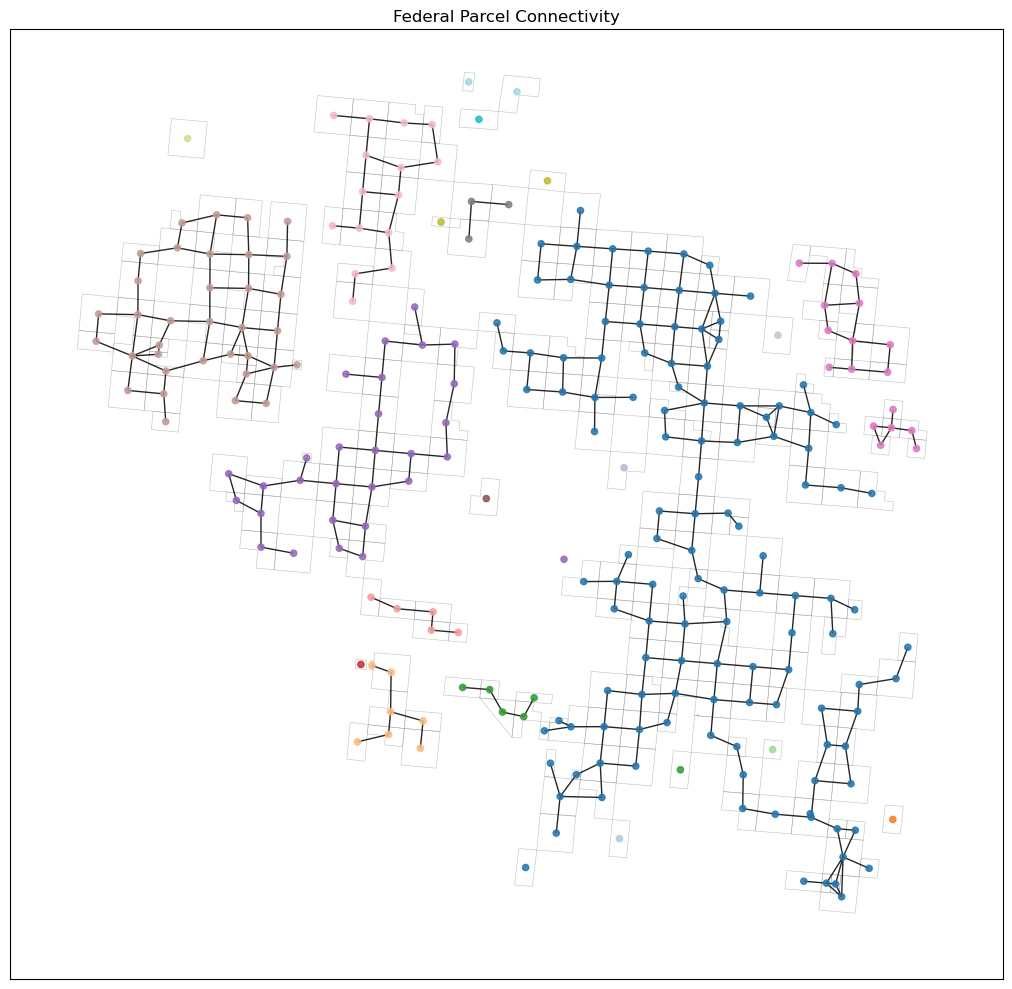

In [10]:
### use projected centroids as node positions
pos = {
    idx: (federal_proj.geometry[idx].centroid.x, federal_proj.geometry[idx].centroid.y)
    for idx in G.nodes()
}

### one color per component
cmap = plt.cm.get_cmap("tab20", len(components))
node_colors = [cmap(group_map[idx]) for idx in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))

### parcel outlines as background
federal_proj.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.4, alpha=0.5)

### draw graph overlaid on parcels
nx.draw(
    G, pos=pos, ax=ax,
    node_color=node_colors,
    node_size=20,
    edge_color="black",
    width=1.0,
    alpha=0.85,
    with_labels=False,
)

ax.set_title("Federal Parcel Connectivity")
ax.set_axis_on()
plt.tight_layout()
plt.show()


In [ ]:
### assign the group id to both geodataframes
federal["group_id"] = federal.index.map(group_map)
federal_proj["group_id"] = federal_proj.index.map(group_map)

### print how many contiguous groups were found
print(f"Found {len(components)} contiguous groups "
      f"(including {sum(1 for c in components if len(c)==1)} isolated single parcels).")

Found 26 contiguous groups (including 16 isolated single parcels).


#### Step 3. Calculate contiguity score for each of the identified groups

Contiguity score is calculated as the total interior shared boundary length divided by convex hull perimeter.

Good explaination of what a convex hull perimeter is: https://scicomp.stackexchange.com/questions/2911/is-there-an-algorithm-to-find-an-almost-convex-hull-given-a-tolerance-angle

In [ ]:
### contiguity score function
def contiguity_score(group_indices, edges_lookup, geometries):

    """
    Calculate a contiguity score for a group of parcels

    Args:
    group_indices (list[int]): indices of parcels belonging to the group
    edges_lookup (list[tuple]): list of (i, j, shared_length_m) rook-neighbor pairs for the full parcel set
    geometries (GeoSeries): parcel geometries projected in meters (EPSG:5070)

    Returns:
    float: ratio of total interior shared edge length to convex hull perimeter — higher means more compact and contiguous
    """

    ### isolated parcels have no neighbors, so score is zero by definition
    if len(group_indices) == 1:
        return 0.0
    
    ### set for O(1) membership checks when filtering edges
    members = set(group_indices)

    ### sum only edges whose both endpoints belong to this group
    interior_len = sum(
        length for (i, j, length) in edges_lookup
        if i in members and j in members
    )

    ### dissolve group into a single geometry to compute the convex hull perimeter
    merged = unary_union([geometries[idx] for idx in group_indices])

    ### shapely convex hull calculation for each group
    hull_perimeter = merged.convex_hull.length

    ### guard against degenerate geometry with zero perimeter
    if hull_perimeter == 0:
        return 0.0
    return interior_len / hull_perimeter

### build group-level summary: score, parcel count, area, dissolved geometry
group_records = []

for gid, sub_df in federal_proj.groupby("group_id"):
    indices = sub_df.index.tolist()
    score = contiguity_score(indices, edges, federal_proj.geometry)
    
    ### use 4326 geometry for output; projected geometry for area calculation
    merged_geom = unary_union([federal.geometry[i] for i in indices])
    area_m2 = sum(federal_proj.geometry[i].area for i in indices)
    group_records.append({
        "group_id":         gid,
        "parcel_count":     len(indices),
        "total_area_m2":    area_m2,
        "total_area_acres": area_m2 * 0.000247105,
        "contiguity_score": score,
        "geometry":         merged_geom,
    })

groups_gdf = gpd.GeoDataFrame(group_records, crs=federal.crs)

print(groups_gdf.sort_values("contiguity_score", ascending=False).head(10))

### save parcels and groups as separate layers in one geopackage
federal.to_file(os.path.join(connectivity_dir, "federal_parcels_grouped.gpkg"), layer="parcels", driver="GPKG")
groups_gdf.to_file(os.path.join(connectivity_dir, "federal_parcels_grouped.gpkg"), layer="groups", driver="GPKG")
print("Saved to data/connectivity/federal_parcels_grouped.gpkg (two layers: parcels, groups)")

INFO:Created 254 records
INFO:Created 26 records


    group_id  parcel_count  total_area_m2  total_area_acres  contiguity_score  \
1          1           123   2.363253e+08      58397.167533          2.374856   
14        14            35   6.492702e+07      16043.790536          1.561736   
10        10            28   5.852765e+07      14462.476168          1.112890   
17        17            15   3.250535e+07       8032.235601          0.807474   
16        16            11   1.629565e+07       4026.737813          0.652735   
15        15             6   4.042288e+06        998.869504          0.447983   
4          4             7   1.074104e+07       2654.165243          0.354884   
6          6             5   5.028505e+06       1242.568745          0.334488   
9          9             5   5.830399e+06       1440.720785          0.320711   
18        18             3   7.953717e+06       1965.403303          0.237462   

                                             geometry  
1   POLYGON ((-104.52477 40.65334, -104.52476 40.6..

#### Step 4. Create map visual of the contiguity groups and their values

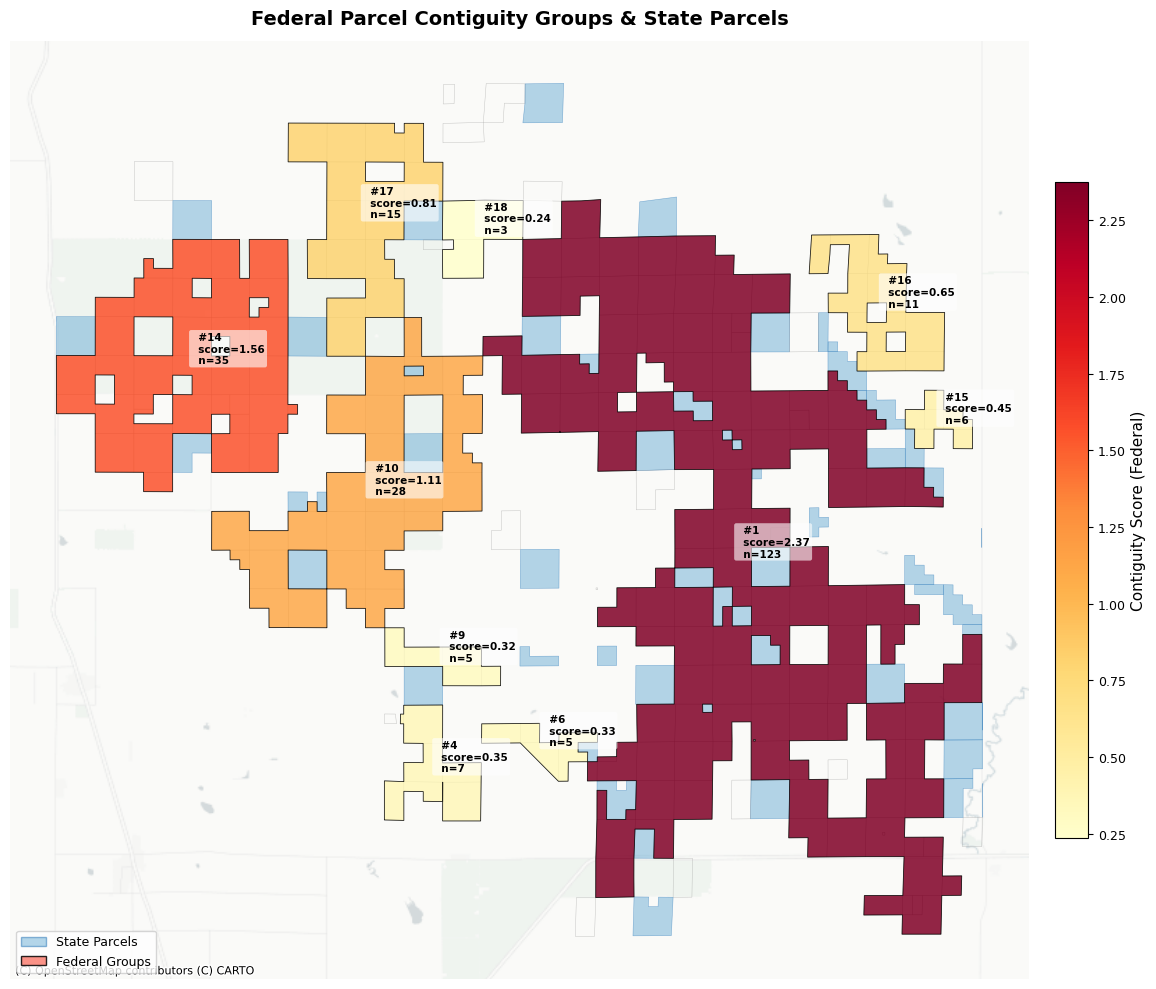

Map saved to figures/federal_contiguity_choropleth.png


In [13]:
### reproject all layers to web mercator for contextily basemap tiles
groups_web = groups_gdf.to_crs(epsg=3857)
parcels_web = federal.to_crs(epsg=3857)
state_web = state.to_crs(epsg=3857)

### filter out isolated single parcels so they don't dominate the color scale
HIDE_ISOLATED = True
if HIDE_ISOLATED:
    groups_plot = groups_web[groups_web["parcel_count"] > 1].copy()
else:
    groups_plot = groups_web.copy()

### color scale: yellow → orange → dark red mapped to contiguity score range
cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(
    vmin=groups_plot["contiguity_score"].min(),
    vmax=groups_plot["contiguity_score"].max()
)

fig, ax = plt.subplots(figsize=(14, 10))

### draw state parcels as a solid muted blue fill
state_web.plot(
    ax=ax,
    facecolor="#6baed6",
    edgecolor="#2171b5",
    linewidth=0.4,
    alpha=0.5,
    zorder=2
)

### draw individual federal parcel boundaries in light gray
parcels_web.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.3,
    alpha=0.5,
    zorder=3
)

### draw dissolved federal groups filled by contiguity score
groups_plot.plot(
    ax=ax,
    column="contiguity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
    zorder=4
)

### add CartoDB basemap
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom="auto")
except Exception:
    pass

### colorbar for federal contiguity scores
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Contiguity Score (Federal)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

### legend to distinguish state vs federal ownership
legend_handles = [
    Patch(facecolor="#6baed6", edgecolor="#2171b5", alpha=0.5, label="State Parcels"),
    Patch(facecolor="salmon", edgecolor="black", alpha=0.85, label="Federal Groups"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.8)

### label every federal group; for multipolygons label each polygon part individually
for _, row in groups_plot.iterrows():
    geom = row.geometry
    parts = sorted(
        geom.geoms if geom.geom_type == "MultiPolygon" else [geom],
        key=lambda g: g.area, reverse=True
    )
    for k, part in enumerate(parts):
        ### largest part gets full label; satellite parts get group ID only
        label = (
            f"  #{int(row['group_id'])}\n  score={row['contiguity_score']:.2f}\n  n={row['parcel_count']}"
            if k == 0 else
            f"  #{int(row['group_id'])}"
        )
        ax.annotate(
            label,
            xy=(part.centroid.x, part.centroid.y),
            fontsize=7.5,
            color="black",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"),
            zorder=5
        )

ax.set_title(
    "Federal Parcel Contiguity Groups & State Parcels",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "federal_contiguity_choropleth.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Map saved to figures/federal_contiguity_choropleth.png")

## Identify land swap locations between federal and state parcels. 

Goal: For each federal contiguity group, find a state parcel that can be swapped into increase the contiguity score of the group. We also need to remove or "release" another equally sized parcel for the trade. 


### Step 1. Define parameters and prepare state parcels

In [ ]:
### parameters
N_GROUPS              = 4        ### number of top-scoring groups to evaluate
MAX_SWAPS_PER_GROUP   = 3        ### maximum proposals retained per group
PARCEL_WIDTH_M        = 1500     ### approximate parcel width in meters
LOCALIZATION_RADIUS_M = 5 * PARCEL_WIDTH_M   ### 7500 m max distance between acquired and released parcel
AREA_FILTER           = 0.10     ### hard cutoff — exclude proposals where area differs by more than 10%
AREA_FLAG             = 0.05     ### soft flag  — warn if area differs by more than 5% (within the filter)
SCORE_DROP_FLAG       = 0.15     ### flag if releasing alone drops group score by more than 15%
STATE_OFFSET          = 100_000  ### index offset to prevent ID collision between federal and state indices

In [ ]:
### project and explode state parcels for geometric analysis
state_proj = state.to_crs(epsg=5070).explode(index_parts=False).reset_index(drop=True)

### Step 2. Identify the top contiguity groups. For now, I'm selecting to do swaps on the highest 4 ranked contiguity groups.

In [ ]:
### select top N groups by contiguity score (multi-parcel only)
top_groups = (
    groups_gdf[groups_gdf["parcel_count"] > 1]
    .nlargest(N_GROUPS, "contiguity_score")
    .reset_index(drop=True)
)
top_group_ids = set(top_groups["group_id"])
print("Evaluating groups:", sorted(top_group_ids))

### Step 3. Find state parcels adjacent to those top 4 contiguity groups.

In [ ]:
### find rook cross-edges between state parcels and top-group federal parcels
cross_edges = []   ### (STATE_OFFSET + s_idx, f_idx, shared_length_m)
state_sindex = state_proj.sindex

# find cross-boundary rook edges between federal parcels (top groups only) and adjacent state parcels
for f_idx, f_row in federal_proj[federal_proj["group_id"].isin(top_group_ids)].iterrows():
    for s_idx in list(state_sindex.intersection(f_row.geometry.bounds)):
        rook, length = is_rook_neighbor(f_row.geometry, state_proj.geometry[s_idx])
        if rook:
            cross_edges.append((STATE_OFFSET + s_idx, f_idx, length))

print(f"Found {len(cross_edges)} state-federal rook-neighbor pairs.")

### Step 4. Filter state parcel candidates.
For now, I only want to swap state parcels that don't border other contiguity groups.

In [ ]:
### map each state parcel node to which federal group(s) it borders
state_borders = defaultdict(set)
for s_node, f_idx, _ in cross_edges:
    state_borders[s_node].add(federal_proj.loc[f_idx, "group_id"])

### Steps 5 & 6. Check state candidates and federal releases
- Check federal release parcels. It can't be released if it would disconnect the group.
- The state parcel centroid must be within the LOCALIZATION_RADIUS_M of the release parcel's centroid.
- Area filter: Swaps can only occur between parcels that have an area difference of less than 10%.

In [ ]:
### unified geometry lookup: federal idx < STATE_OFFSET, state idx >= STATE_OFFSET
def get_geom(idx):
    return state_proj.geometry[idx - STATE_OFFSET] if idx >= STATE_OFFSET else federal_proj.geometry[idx]

### contiguity score for an arbitrary member set and edge list
def score_flex(members, edge_list):
    ### ratio of interior shared edge length to convex hull perimeter
    if len(members) <= 1:
        return 0.0
    m = set(members)
    interior = sum(l for i, j, l in edge_list if i in m and j in m)
    hull_len = unary_union([get_geom(i) for i in m]).convex_hull.length
    return interior / hull_len if hull_len > 0 else 0.0

### evaluate swap proposals
proposals = []
print("Evaluating swaps (may take a moment)...")

for _, grow in top_groups.iterrows():
    gid        = grow["group_id"]
    orig_score = grow["contiguity_score"]
    fed_list   = federal_proj[federal_proj["group_id"] == gid].index.tolist()
    fed_set    = set(fed_list)

    ### internal federal edges and subgraph for this group
    grp_edges = [(i, j, l) for i, j, l in edges if i in fed_set and j in fed_set]
    G_sub     = G.subgraph(fed_list).copy()

    ### state candidates bordering only this group (no inter-group bridges)
    cand_state = [sn for sn, grps in state_borders.items() if grps == {gid}]

    ### best proposal keyed first by state_idx, then deduplicated by fed_release_idx
    by_state = {}   ### state_idx  → best proposal for that state parcel
    by_fed   = {}   ### fed_rel_idx → best proposal for that release parcel

    for s_node in cand_state:
        s_idx      = s_node - STATE_OFFSET
        s_geom     = state_proj.geometry[s_idx]
        s_area     = s_geom.area
        s_centroid = s_geom.centroid

        ### cross-edges from this state parcel into the group
        s_cross = [(sn, fi, l) for sn, fi, l in cross_edges if sn == s_node and fi in fed_set]

        ### rebuild group graph with state parcel added, recheck articulation points
        G_aug = G_sub.copy()
        G_aug.add_node(s_node)
        for _, fi, _ in s_cross:
            G_aug.add_edge(s_node, fi)
        aug_art   = set(nx.articulation_points(G_aug))
        aug_edges = grp_edges + s_cross

        for f_rel in fed_list:
            if f_rel in aug_art:
                continue   ### removing would disconnect the group

            ### skip if release parcel is too far from the acquisition site
            if s_centroid.distance(federal_proj.geometry[f_rel].centroid) > LOCALIZATION_RADIUS_M:
                continue

            f_area    = federal_proj.geometry[f_rel].area
            area_diff = abs(s_area - f_area) / max(s_area, f_area)

            ### hard area filter — skip if mismatch exceeds AREA_FILTER
            if area_diff > AREA_FILTER:
                continue

            ### score after full swap: acquire s_node, release f_rel
            swap_members = [i for i in fed_list if i != f_rel] + [s_node]
            swap_edges   = [(i, j, l) for i, j, l in aug_edges if i != f_rel and j != f_rel]
            swap_score   = score_flex(swap_members, swap_edges)
            net_gain     = swap_score - orig_score

            if net_gain <= 0:
                continue

            ### score if only releasing f_rel — for flagging significant standalone drops
            rel_score = score_flex(
                [i for i in fed_list if i != f_rel],
                [(i, j, l) for i, j, l in grp_edges if i != f_rel and j != f_rel]
            )
            rel_drop = orig_score - rel_score

            prop = dict(
                group_id        = gid,
                orig_score      = orig_score,
                swap_score      = swap_score,
                net_gain        = net_gain,
                state_idx       = s_idx,
                fed_release_idx = f_rel,
                state_acres     = round(s_area * 0.000247105, 1),
                fed_acres       = round(f_area * 0.000247105, 1),
                area_diff_pct   = round(area_diff * 100, 1),
                area_flag       = area_diff > AREA_FLAG,
                rel_drop        = rel_drop,
                rel_flag        = rel_drop > SCORE_DROP_FLAG * orig_score,
            )

            ### keep best proposal per state parcel
            if s_idx not in by_state or net_gain > by_state[s_idx]["net_gain"]:
                by_state[s_idx] = prop

    ### deduplicate by release parcel, each federal parcel appears at most once
    for prop in by_state.values():
        f_rel = prop["fed_release_idx"]
        if f_rel not in by_fed or prop["net_gain"] > by_fed[f_rel]["net_gain"]:
            by_fed[f_rel] = prop

    top_for_group = sorted(by_fed.values(), key=lambda p: p["net_gain"], reverse=True)
    proposals.extend(top_for_group[:MAX_SWAPS_PER_GROUP])
    print(f"  Group {gid}: {len(top_for_group)} valid swap candidates found.")

### ranked results 
if not proposals:
    print("\nNo valid swap proposals found.")
else:
    proposals_df = (
        pd.DataFrame(proposals)
        .sort_values("net_gain", ascending=False)
        .reset_index(drop=True)
    )
    proposals_df.index += 1   ### 1-based rank

    print("\n Top Land Swap Proposals ")
    for rank, row in proposals_df.iterrows():
        flags = []
        if row["area_flag"]:
            flags.append(
                f"AREA MISMATCH {row['area_diff_pct']}% "
                f"(acquire={row['state_acres']} ac, release={row['fed_acres']} ac)"
            )
        if row["rel_flag"]:
            flags.append(f"RELEASE ALONE DROPS SCORE BY {row['rel_drop']:.4f}")
        flag_str = "  ⚠ " + " | ".join(flags) if flags else ""
        print(
            f"  #{rank}  group={row['group_id']}  "
            f"{row['orig_score']:.4f} → {row['swap_score']:.4f}  (gain +{row['net_gain']:.4f})"
            f"  acquire state[{row['state_idx']}]  release fed[{row['fed_release_idx']}]"
            f"{flag_str}"
        )

Evaluating groups: [1, 10, 14, 17]
Found 100 state-federal rook-neighbor pairs.
Evaluating swaps (may take a moment)...
  Group 1: 13 valid swap candidates found.
  Group 14: 2 valid swap candidates found.
  Group 10: 2 valid swap candidates found.
  Group 17: 1 valid swap candidates found.

── Top Land Swap Proposals ─────────────────────────────────────────
  #1  group=10  1.1129 → 1.2759  (gain +0.1630)  acquire state[17]  release fed[114]
  #2  group=17  0.8075 → 0.9360  (gain +0.1285)  acquire state[54]  release fed[192]
  #3  group=10  1.1129 → 1.1973  (gain +0.0844)  acquire state[33]  release fed[170]
  #4  group=14  1.5617 → 1.6226  (gain +0.0609)  acquire state[34]  release fed[124]
  #5  group=1  2.3749 → 2.4315  (gain +0.0566)  acquire state[5]  release fed[4]
  #6  group=1  2.3749 → 2.4287  (gain +0.0538)  acquire state[44]  release fed[228]
  #7  group=1  2.3749 → 2.4201  (gain +0.0452)  acquire state[11]  release fed[82]
  #8  group=14  1.5617 → 1.5745  (gain +0.0128)  a

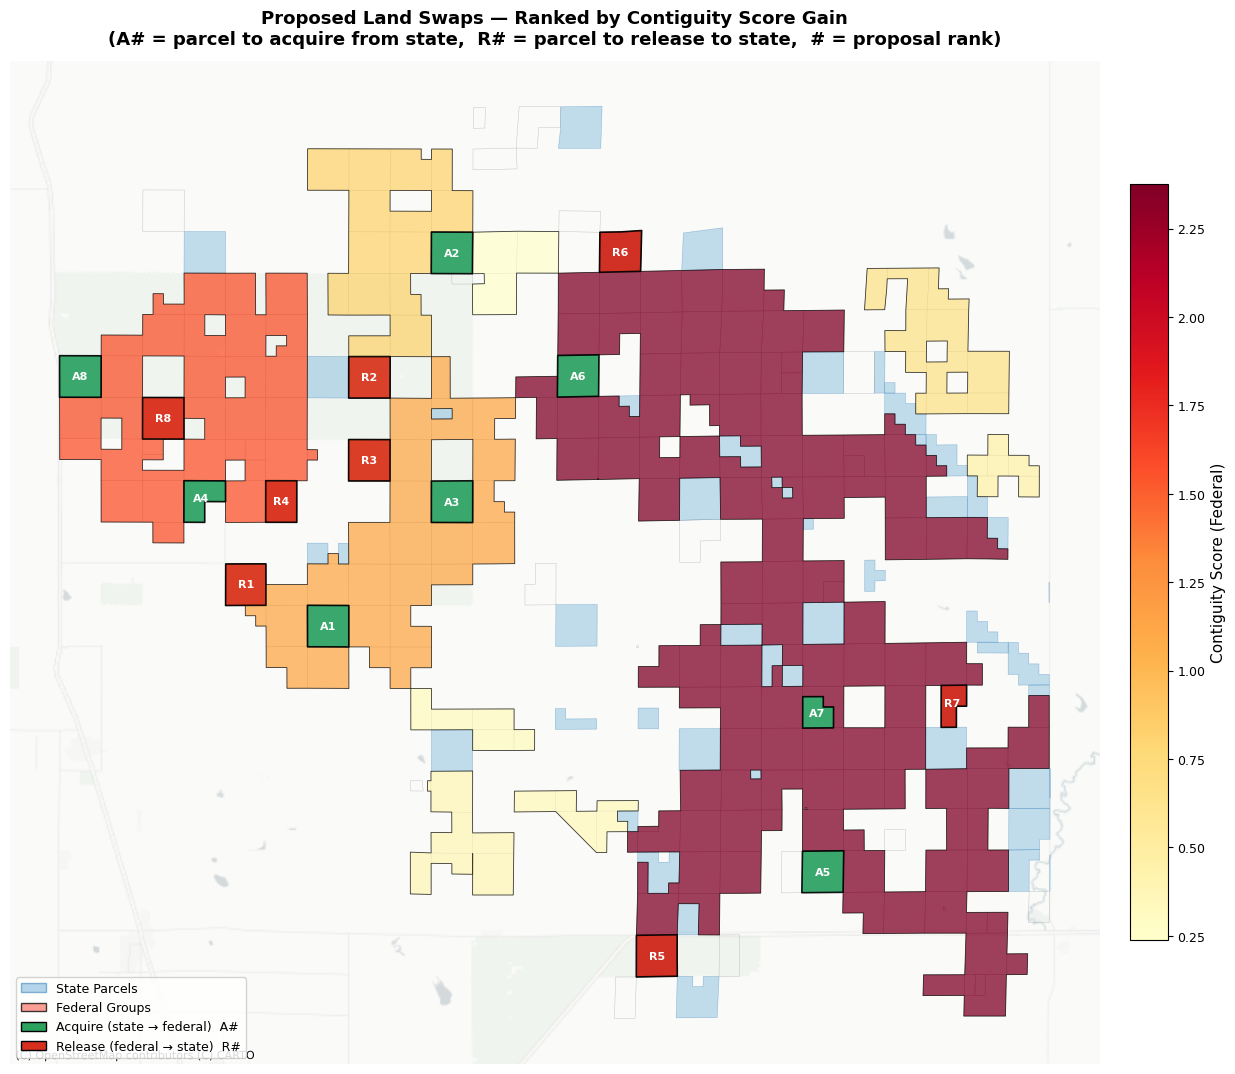

Map saved to figures/land_swap_proposals.png


In [15]:
### reproject all layers for basemap display
groups_web     = groups_gdf.to_crs(epsg=3857)
parcels_web    = federal.to_crs(epsg=3857)
state_web      = state.to_crs(epsg=3857)
state_proj_web = state_proj.to_crs(epsg=3857)
fed_proj_web   = federal_proj.to_crs(epsg=3857)

HIDE_ISOLATED = True
groups_plot = groups_web[groups_web["parcel_count"] > 1].copy() if HIDE_ISOLATED else groups_web.copy()

cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(
    vmin=groups_plot["contiguity_score"].min(),
    vmax=groups_plot["contiguity_score"].max()
)

fig, ax = plt.subplots(figsize=(16, 11))

### base layers: state parcels, federal boundaries, federal group choropleth
state_web.plot(ax=ax, facecolor="#6baed6", edgecolor="#2171b5", linewidth=0.4, alpha=0.4, zorder=2)
parcels_web.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.3, alpha=0.5, zorder=3)
groups_plot.plot(ax=ax, column="contiguity_score", cmap=cmap, norm=norm,
                 edgecolor="black", linewidth=0.6, alpha=0.75, zorder=4)

### add CartoDB basemap
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom="auto")
except Exception:
    pass

### overlay acquired (green) and released (red) parcels as batched layers
ACQUIRE_COLOR = "#2ca25f"
RELEASE_COLOR = "#d7301f"

acq_geoms = [state_proj_web.geometry[row["state_idx"]] for _, row in proposals_df.iterrows()]
rel_geoms = [fed_proj_web.geometry[row["fed_release_idx"]] for _, row in proposals_df.iterrows()]

gpd.GeoDataFrame(geometry=acq_geoms, crs="EPSG:3857").plot(
    ax=ax, facecolor=ACQUIRE_COLOR, edgecolor="black", linewidth=1.2, alpha=0.9, zorder=6)
gpd.GeoDataFrame(geometry=rel_geoms, crs="EPSG:3857").plot(
    ax=ax, facecolor=RELEASE_COLOR, edgecolor="black", linewidth=1.2, alpha=0.9, zorder=6)

### label each proposal pair directly at parcel centroids
for rank, row in proposals_df.iterrows():
    acq_c = state_proj_web.geometry[row["state_idx"]].centroid
    rel_c = fed_proj_web.geometry[row["fed_release_idx"]].centroid

    ax.annotate(f"A{rank}", xy=(acq_c.x, acq_c.y), fontsize=8, fontweight="bold",
                color="white", ha="center", va="center", zorder=7)
    ax.annotate(f"R{rank}", xy=(rel_c.x, rel_c.y), fontsize=8, fontweight="bold",
                color="white", ha="center", va="center", zorder=7)

### colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Contiguity Score (Federal)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

### legend
legend_handles = [
    Patch(facecolor="#6baed6",     edgecolor="#2171b5", alpha=0.5,  label="State Parcels"),
    Patch(facecolor="salmon",      edgecolor="black",   alpha=0.75, label="Federal Groups"),
    Patch(facecolor=ACQUIRE_COLOR, edgecolor="black",               label="Acquire (state → federal)  A#"),
    Patch(facecolor=RELEASE_COLOR, edgecolor="black",               label="Release (federal → state)  R#"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.85)

ax.set_title(
    "Proposed Land Swaps — Ranked by Contiguity Score Gain\n"
    "(A# = parcel to acquire from state,  R# = parcel to release to state,  # = proposal rank)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "land_swap_proposals.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Map saved to figures/land_swap_proposals.png")

In [16]:
### print swap proposal summary
print("=" * 62)
print("  LAND SWAP PROPOSAL SUMMARY")
print("=" * 62)

for rank, row in proposals_df.iterrows():
    s_area  = row["state_acres"]
    f_area  = row["fed_acres"]
    flags   = []
    if row["area_flag"]:
        flags.append(f"area mismatch {row['area_diff_pct']}% (acquire {s_area} ac vs release {f_area} ac)")
    if row["rel_flag"]:
        flags.append(f"releasing alone drops score by {row['rel_drop']:.4f}")

    print(f"\n  Proposal #{rank}  |  Group {int(row['group_id'])}")
    print(f"    Contiguity score : {row['orig_score']:.4f}  →  {row['swap_score']:.4f}  (+{row['net_gain']:.4f})")
    print(f"    Acquire          : state parcel [{int(row['state_idx'])}]  ({s_area} ac)")
    print(f"    Release          : federal parcel [{int(row['fed_release_idx'])}]  ({f_area} ac)")
    print(f"    Area difference  : {row['area_diff_pct']}%")
    if flags:
        for flag in flags:
            print(f"    ⚠  {flag}")

print("\n" + "=" * 62)

  LAND SWAP PROPOSAL SUMMARY

  Proposal #1  |  Group 10
    Contiguity score : 1.1129  →  1.2759  (+0.1630)
    Acquire          : state parcel [17]  (640.6 ac)
    Release          : federal parcel [114]  (624.4 ac)
    Area difference  : 2.5%

  Proposal #2  |  Group 17
    Contiguity score : 0.8075  →  0.9360  (+0.1285)
    Acquire          : state parcel [54]  (638.3 ac)
    Release          : federal parcel [192]  (640.1 ac)
    Area difference  : 0.3%

  Proposal #3  |  Group 10
    Contiguity score : 1.1129  →  1.1973  (+0.0844)
    Acquire          : state parcel [33]  (642.5 ac)
    Release          : federal parcel [170]  (639.8 ac)
    Area difference  : 0.4%

  Proposal #4  |  Group 14
    Contiguity score : 1.5617  →  1.6226  (+0.0609)
    Acquire          : state parcel [34]  (483.9 ac)
    Release          : federal parcel [124]  (482.0 ac)
    Area difference  : 0.4%

  Proposal #5  |  Group 1
    Contiguity score : 2.3749  →  2.4315  (+0.0566)
    Acquire          : s